# Zomato Restaurant Data Analysis

## Objective
Analyze restaurant and review data to extract insights on ratings, cuisines, location preferences, and factors affecting ratings.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading dataset

In [72]:
df = pd.read_csv("zomato.csv", encoding='latin-1')

# remove duplicates
df.drop_duplicates(inplace=True)

# clean rate column
df['rate'] = df['rate'].astype(str)

df['rate'] = df['rate'].replace('NEW', np.nan)
df['rate'] = df['rate'].replace('-', np.nan)

df['rate'] = df['rate'].str.replace('/5', '', regex=False)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# clean cost column
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

# check
df[['rate', 'approx_cost(for two people)']].head()

,rate,approx_cost(for two people)
0,4.1,800.0
1,4.1,800.0
2,3.8,800.0
3,3.7,300.0
4,3.8,600.0


In [63]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,NaN,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,NaN,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,NaN,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,NaN,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,NaN,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [54]:
df = df[df['online_order'].isin(['Yes', 'No'])]
df['online_order'].unique()
# df = pd.read_csv("zomato.csv", encoding='latin-1', sep=',')

array(['Yes', 'No'], dtype=object)

## Data understanding

In [35]:
df.shape

(56252, 13)

In [36]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [38]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


## Missing Values Analysis
Checking null values present in the dataset.

In [39]:
df.isnull().sum()

address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64

## Removing Duplicate Records

In [69]:
df.drop_duplicates(inplace=True)

In [73]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , nan, 4.2, 3.9, 3.1, 3. , 3.2, 3.3,
       2.8, 4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [42]:
df['rate'] = df['rate'].replace('NEW', np.nan)
df['rate'] = df['rate'].replace('-', np.nan)

df['rate'] = df['rate'].str.replace('/5', '')

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [74]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [76]:
df[['rate', 'approx_cost(for two people)']].head()

,rate,approx_cost(for two people)
0,4.1,800.0
1,4.1,800.0
2,3.8,800.0
3,3.7,300.0
4,3.8,600.0


## Ratings Distribution
Analyzing how restaurant ratings are distributed.

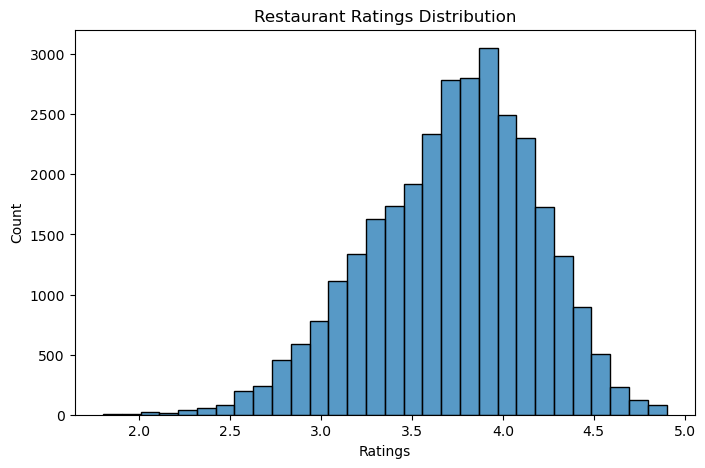

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=30)

plt.title("Restaurant Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

### Observation

Most restaurants have ratings between 3.5 and 4.2.

## Online Order Analysis
Checking how many restaurants support online ordering.

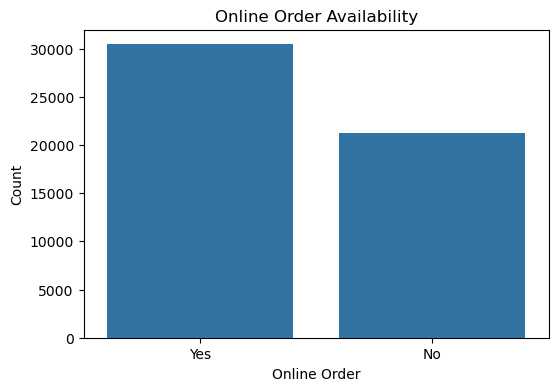

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(x='online_order', data=df)

plt.title("Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Count")

plt.show()

### Observation

Most restaurants are available for online service.

## Top Locations

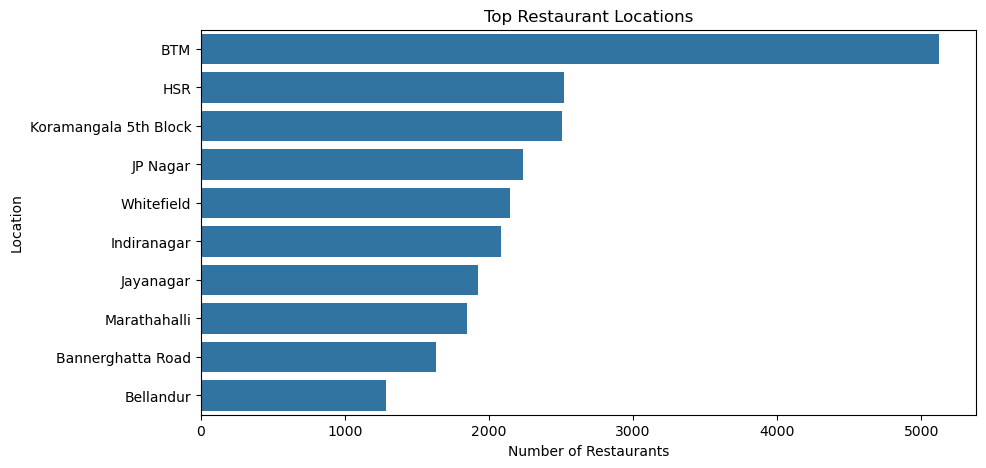

In [57]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top Restaurant Locations")

plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

### Observation

Location like BTM layout have top restaurant 

## Cuisine Analysis

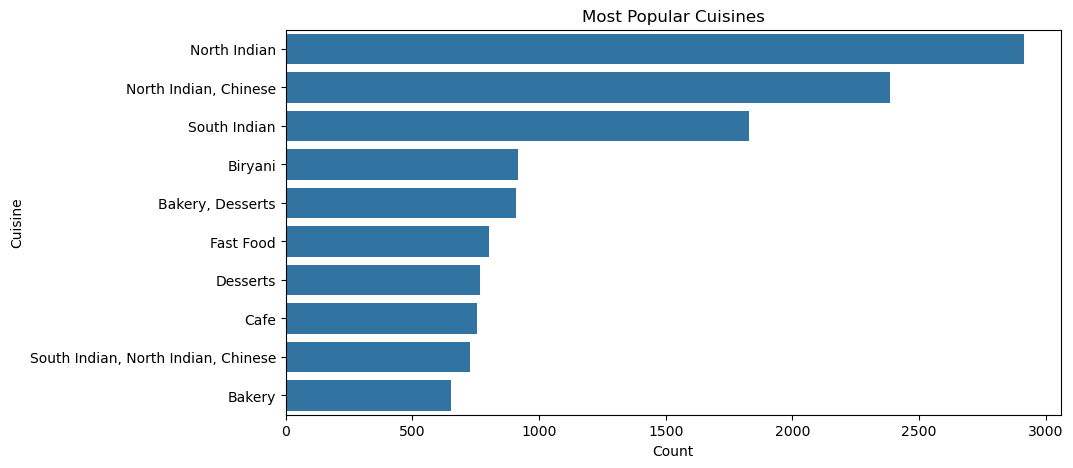

In [58]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Most Popular Cuisines")

plt.xlabel("Count")
plt.ylabel("Cuisine")

plt.show()

### Observation

Besides Bangaluru is in South India still most popular cuisines are North Indian.

## Price vs Rating Graph

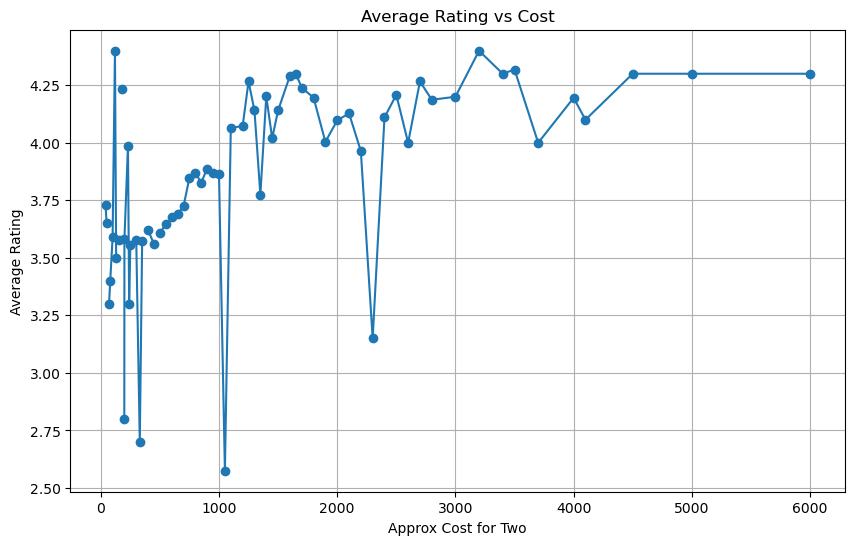

In [82]:
plt.figure(figsize=(10,6))

plt.plot(
    df.groupby('approx_cost(for two people)')['rate'].mean(),
    marker='o'
)

plt.title("Average Rating vs Cost")
plt.xlabel("Approx Cost for Two")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

## Heatmap

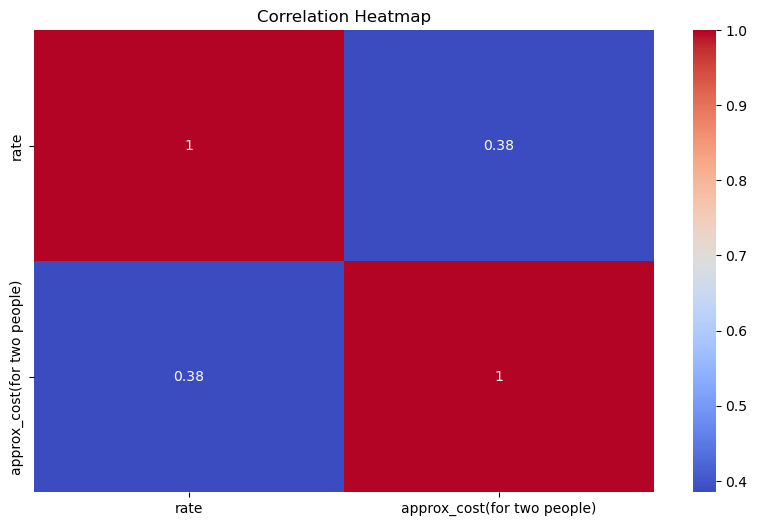

In [86]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation between restaurant cost and ratings is moderate (0.38). 
This indicates that higher-priced restaurants tend to have slightly better ratings, 
but price alone does not strongly determine customer satisfaction.

# Key Insights

- Most restaurants have ratings between 3.5 and 4.2.
- Online ordering is supported by the majority of restaurants.
- Certain locations contain a high concentration of restaurants.
- Mid-range restaurants tend to receive balanced customer ratings.
- Popular cuisines dominate restaurant listings.

# Recommendations

1. Focus on high-demand restaurant locations.
2. Promote restaurants with online ordering facilities.
3. Encourage customer reviews to improve visibility.
4. Partner with highly rated cuisine categories.
5. Optimize pricing strategies based on customer trends.